# Create your own Xarray Backend
In this lesson, we will learn about and how to create your own custom xarray backend

:::{admonition} Learning Goals
- Learn about xarray's support for custom backends
- Learn how to use a custom `imageio` backend to open and manipulate GIFs
- Learn how to extend the `imagegio` backend to write out a GIF
:::

## Why should you create your own Xarray backend?

- Allows you to use xarray's interface
    - Attribute-like syntax, dict-like syntax and label based indexing
- You don’t need to integrate any code in Xarray
- Easy and fast!


## Setting up the BackendEntrypoint

To set up a `BackendEntrypoint` we can implement a subclass of `BackendEntrypoint` and expose the `open_dataset` method to it. For this tutorial we have the `ImageIOBackend` already defined but we will extend the functionally to write GIFS.

In [135]:
image_path = '../../advanced/backends/ocean.gif'
image_path = '../../advanced/backends/io.gif'


We can write a simple image reader function that we can then plug into our `MyBackendEntrypoint` class. For this example we are going to use `imageio` an image reader and writer library. With `imageio` you can read an image file with `iio.imopen`

:::{note}
The `ImageIOBackend` also defines a `ImageIOBackendArray` with basic indexing.
:

In [136]:
import imageio as iio
from xarray.backends import BackendEntrypoint

def imageio_open(
    filename_or_obj,
):
    img = iio.imopen(filename_or_obj, io_mode="r")
    return img.read()

imageio_open(image_path)

class MyImageReader(BackendEntrypoint):
    def open_dataset(
        self,
        filename_or_obj,
        *,
        drop_variables=None,
    ):
        return imageio_open(filename_or_obj)

MyImageReader().open_dataset(image_path)

array([[[[184, 192, 230],
         [184, 192, 230],
         [184, 192, 230],
         ...,
         [198, 196, 227],
         [198, 196, 227],
         [198, 196, 227]],

        [[184, 192, 230],
         [184, 192, 230],
         [184, 192, 230],
         ...,
         [198, 196, 227],
         [198, 196, 227],
         [198, 196, 227]],

        [[184, 192, 230],
         [184, 192, 230],
         [184, 192, 230],
         ...,
         [198, 196, 227],
         [198, 196, 227],
         [198, 196, 227]],

        ...,

        [[164, 163, 174],
         [164, 163, 174],
         [164, 163, 174],
         ...,
         [183, 184, 199],
         [183, 184, 199],
         [183, 184, 199]],

        [[164, 163, 174],
         [164, 163, 174],
         [164, 163, 174],
         ...,
         [183, 184, 199],
         [183, 184, 199],
         [183, 184, 199]],

        [[168, 163, 184],
         [164, 163, 174],
         [164, 163, 174],
         ...,
         [183, 184, 199],
        

## Reading image data

Lets use our `ImageIOBackend` to open a GIF.


In [137]:
from imageio_ import ImageIOBackend
import xarray as xr


gif_ds = xr.open_dataset(image_path, engine=ImageIOBackend)
gif_ds

<xarray.Dataset> Size: 66MB
Dimensions:  (time: 54, height: 640, width: 640, color: 3)
Coordinates:
  * time     (time) timedelta64[ms] 432B 00:00:00 ... 00:00:02.120000
  * color    (color) <U5 60B 'red' 'green' 'blue'
Dimensions without coordinates: height, width
Data variables:
    data     (time, height, width, color) uint8 66MB ...

### Examining our image dataset

Since our image is a `Dataset` object we can use xarray's interface for `Dataset` objects.

Let's try listing all of the variables, dimensions and selecting data

In [138]:
gif_ds.variables

Frozen({'data': <xarray.Variable (time: 54, height: 640, width: 640, color: 3)> Size: 66MB
[66355200 values with dtype=uint8]
Attributes:
    loop:     0, 'time': <xarray.IndexVariable 'time' (time: 54)> Size: 432B
array([   0,   40,   80,  120,  160,  200,  240,  280,  320,  360,  400,  440,
        480,  520,  560,  600,  640,  680,  720,  760,  800,  840,  880,  920,
        960, 1000, 1040, 1080, 1120, 1160, 1200, 1240, 1280, 1320, 1360, 1400,
       1440, 1480, 1520, 1560, 1600, 1640, 1680, 1720, 1760, 1800, 1840, 1880,
       1920, 1960, 2000, 2040, 2080, 2120], dtype='timedelta64[ms]'), 'color': <xarray.IndexVariable 'color' (color: 3)> Size: 60B
array(['red', 'green', 'blue'], dtype='<U5')})

We can list our dimensions

In [139]:
gif_ds.dims

FrozenMappingWarningOnValuesAccess({'time': 54, 'height': 640, 'width': 640, 'color': 3})

Let's try getting our `DataArray`

In [140]:
gif_ds['data'].data

array([[[[184, 192, 230],
         [184, 192, 230],
         [184, 192, 230],
         ...,
         [198, 196, 227],
         [198, 196, 227],
         [198, 196, 227]],

        [[184, 192, 230],
         [184, 192, 230],
         [184, 192, 230],
         ...,
         [198, 196, 227],
         [198, 196, 227],
         [198, 196, 227]],

        [[184, 192, 230],
         [184, 192, 230],
         [184, 192, 230],
         ...,
         [198, 196, 227],
         [198, 196, 227],
         [198, 196, 227]],

        ...,

        [[164, 163, 174],
         [164, 163, 174],
         [164, 163, 174],
         ...,
         [183, 184, 199],
         [183, 184, 199],
         [183, 184, 199]],

        [[164, 163, 174],
         [164, 163, 174],
         [164, 163, 174],
         ...,
         [183, 184, 199],
         [183, 184, 199],
         [183, 184, 199]],

        [[168, 163, 184],
         [164, 163, 174],
         [164, 163, 174],
         ...,
         [183, 184, 199],
        

## GIF metadata
We can examine, update and add metadata to our `Dataset` object. 

We can examine the attributes in our GIF "data" variable with the `.attrs` method

In [177]:
gif_ds.data.attrs

{'loop': 0, 'fps': 50}

## Exercise

::::{admonition} Exercise
:class: tip

Can you add a new attribute to our GIF "data" variable called "fps". This is the frames per second we can write our GIF to. You can set it to any value.

:::{admonition} Solution
:class: dropdown

```python
gif_ds.data.attrs['fps'] = 100
```
:::
::::

### GIF writer
We can extend our backend with an GIF writer. Here we use `matplotlib`'s animation functions and `PillowWriter`

In [176]:
from imageio_ import ImageIOBackend
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
import matplotlib.animation as animation


class SimpleImageWrtiter(ImageIOBackend):
    def to_giff(
        self,
        dataset,
        variable,
        time_dim,
        out_filename,
        **kwargs,
    ):
        fig, ax = plt.subplots()

        frames = []
        variable_da = dataset[variable]

        for time in variable_da[time_dim]:
            variable_da = variable_da.transpose('time', 'width', 'height', 'color')
            to_plot = ax.pcolormesh(
                variable_da.height,
                variable_da.width,
                variable_da.sel(time=time),
                animated=True,
                shading="auto",
                **kwargs,
            )

            frames.append([to_plot])

        writer = PillowWriter(fps=variable_da.attrs['fps'], **kwargs)
        ani = animation.ArtistAnimation(fig, frames, blit=True, repeat=True)
        ani.save(filename=out_filename, writer=writer)


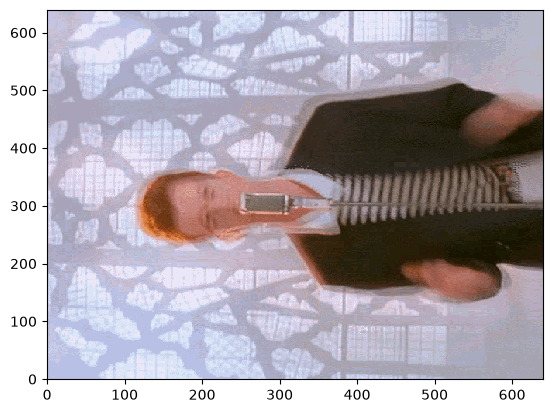

In [ ]:
img_writer = SimpleImageWrtiter()
img_writer.to_giff(gif_ds, 'data', 'time', 'test_again.gif')